# Lagged Predictions of Next Week Alcohol Use for Precision Mental

Health Support

Kendra Wyant (Department of Psychology, University of Wisconsin-Madison)  
Jiachen (Coco) Yu (Department of Psychology, University of Wisconsin-Madison)  
Gaylen E. Fronk (Department of Psychology, University of Wisconsin-Madison)  
John J. Curtin (Department of Psychology, University of Wisconsin-Madison)  
May 20, 2024

This study found some pretty cool results that have both high impact and important clinical implications. For example …

In [ ]:
suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(source("https://github.com/jjcurtin/lab_support/blob/main/format_path.R?raw=true"))
suppressPackageStartupMessages(library(tidyposterior))

path_models_lag <- format_path(str_c("studydata/risk/models/lag"))

In [ ]:
test_metrics_0 <- read_csv(file.path(path_models_lag, 
                                        "test_metrics_1week_0_v2_nested.csv"), 
                              col_types = cols()) |> 
  filter(.metric == "roc_auc") |> 
  select(outer_split_num, "lag0" = .estimate)

test_metrics_24 <- read_csv(file.path(path_models_lag, 
                                       "test_metrics_1week_24_v2_nested.csv"),
                             col_types = cols()) |> 
  filter(.metric == "roc_auc") |> 
  select(outer_split_num, "lag24" = .estimate)

test_metrics_72 <- read_csv(file.path(path_models_lag, 
                                        "test_metrics_1week_72_v2_nested.csv"),
                              col_types = cols()) |> 
  filter(.metric == "roc_auc") |> 
  select(outer_split_num, "lag72" = .estimate)

test_metrics_168 <- read_csv(file.path(path_models_lag, 
                                        "test_metrics_1week_168_v2_nested.csv"), 
                              col_types = cols()) |> 
  filter(.metric == "roc_auc") |> 
  select(outer_split_num, "lag168" = .estimate)

test_metrics_336 <- read_csv(file.path(path_models_lag, 
                                       "test_metrics_1week_336_v2_nested.csv"),
                             col_types = cols()) |> 
  filter(.metric == "roc_auc") |> 
  select(outer_split_num, "lag336" = .estimate)

test_metrics_all <- test_metrics_0 |> 
  left_join(test_metrics_24, by = c("outer_split_num")) |> 
  left_join(test_metrics_72, by = c("outer_split_num")) |>
  left_join(test_metrics_168, by = c("outer_split_num")) |>
  left_join(test_metrics_336, by = c("outer_split_num")) |> 
  mutate(fold_num = rep(1:10, 3),
         repeat_num = c(rep(1, 10), rep(2, 10), rep(3, 10))) |> 
  select(-outer_split_num)

## Introduction

### Precision Medicine

Precision medicine has been a goal in healthcare for over half a century \[@derubeisHistoryCurrentStatus2019\]. Today, this approach is also applied to chronic mental health conditions, like substance use disorders (i.e., precision mental health). Precision mental health uses individual characteristics to guide initial treatment matching and adaptive continuing care over time. It requires dense, long-term monitoring of symptoms and related states, for interventions to be tailored to an individual’s needs and preferences at any given moment \[@bickmanAchievingPrecisionMental2016a\]. Essentially, it aims to identify both *when* and *how* to intervene.

### Personal Sensing and Machine Learning

Using algorithms to time (*when*) and select personalized interventions (*how*) for substance use may now be possible, thanks to personal sensing and high-dimensional machine learning algorithms. Personal sensing allows for frequent, longitudinal monitoring of individuals’ affect, behavior, and cognitions in their day-to-day lives \[@mohrPersonalSensingUnderstanding2017\]. These data can then be used as inputs for machine learning algorithms to predict the probability of specific outcomes (e.g., lapse risk) and identify the top features contributing to those predictions.

### EMA

Ecological momentary assessment (EMA) may be particularly well-suited for these algorithms. It offers momentary subjective insight into constructs that can be easily mapped onto modular forms of treatment, such as the relapse prevention model \[@marlattRelapsePreventionMaintenance1985; @witkiewitzRelapsePreventionAlcohol2004\]. EMA also appears to be well tolerated by individuals with substance use disorders \[@wyantAcceptabilityPersonalSensing2023\]. Thus, it can serve as an important signal for predicting substance use outcomes and interpreting clinically relevant features over a sustained period.

### Promising Preliminary Work

Promising preliminary work suggests it is possible to build EMA models that predict immediate lapses back to substance use \[@waltersUsingMachineLearning2021; @baeMobilePhoneSensors2018; @soysterPooledPersonspecificMachine2022; @chihPredictiveModelingAddiction2014\]. In a previous study from our group, we demonstrated that we can do this very well. Model features were engineered from raw scores and longitudinal change in responses to 4X daily EMAs. EMA questions were designed to measure theoretically-implicated risk factors including past use, craving, past pleasant events, past and future risky situations, past and future stressful events, emotional valence and arousal, and self-efficacy \[for reviews, see @marlattRelapsePreventionMaintenance1985; @fronkStressAllostasisSubstance2020; @witkiewitzModelingComplexityPosttreatment2007\]. We showed that it was possible to predict immediate alcohol lapses within the next week, day, and hour with clinically meaningful accuracy - area under the receiver operating curves (auROCs) of 0.89, 0.90, and 0.93, respectively \[@wyantMachineLearningModels2023\]. We also characterized the relative importance of features contributing to these risk probabilities for specific individuals at specific moments in time. These models are well-suited for just-in-time adaptive interventions (JITAIs) integrated within an app to address these immediate risks.

### Many Interventions Happen Outside of an App

However, some interventions take time to set up. For example, someone who has reported recent past alcohol use and low abstinence self-efficacy might be encouraged to attend a self-help meeting, plan an outing with important people in their life, or schedule an appointment with a therapist. These multimodal interventions (i.e., combined human and digital interventions) are not available 24/7. A *time-lagged* model with predictions shifted further into the future could provide patients with increased lead time to implement supports that might not be immediately available to them.

### Current Study

In this study, we compare the performance of one of our models from a previous study with models using increased lag time between predictions and outcomes. Specifically, we use the same EMA features as our immediate model and train new models to predict the probability of a lapse beginning one day (24 hours), three days (72 hours), one week (168 hours), or two weeks (336 hours) into the future. Our primary objective is to assess how model performance degrades with increasing lag time.

## Methods

### Participants

We recruited participants in early recovery (1-8 weeks of abstinence) from moderate to severe alcohol use disorder in Madison, Wisconsin, US for a three month longitudinal study. We used data from all participants included in our previous study (N = 151; see \[@wyantMachineLearningModels2023\] for enrollment, disposition, and demographic information).

### Lapse Labels

We predicted lapses occurring in one week windows. Predictions were updated hourly. Therefore our models provided hour-by-hour predictions of future probability of an alcohol lapse within a one week window shifted at various time points (i.e., lags) into the future (no lag and one day, three day, one week, or two week lagged predictions). The first prediction for each participant occurs 24 hours + lag time (in hours) after their study start date. For example, the first prediction for the one day lagged prediction model would be 48 hours after participants’ start date.

A prediction window was labeled *lapse* if the start date/hour of any drinking episode fell within that window. A window was labeled *no lapse* if no alcohol use occurred within that window +/- 6 hours. If no alcohol use occurred within the window but did occur within 6 hours of the start or end of the window, the window was excluded. We had previously used a more conservative fence around lapse exclusions (24 hours vs. 6 hours), however, after re-evaluation we deemed this to be too conservative.

### Feature Engineering

Features were calculated using only data collected before the start of each prediction window. For our no lag models this included all data prior to the hour of the start of the prediction window. For our lagged models, the last EMA data used for feature engineering were collected up to one day, three days, one week, or two weeks prior to the start of the prediction window.

Following our previous work, features were derived from three data sources:

-   *Demographics*: We created quantitative features for age and personal income, and dummy-coded features for sex, race/ethnicity, marital status, education, and employment.

-   *Day and time of prediction window onset*: We created dummy-coded features to indicate time of day and day of week that the prediction window began.

-   *Previous EMA responses*: We created raw EMA and change features for varying scoring epochs before the start of the prediction window for all EMA items (i.e., 12, 24, 48, 72, and 168 hours). Raw features included min, max, and median scores for each EMA question across all EMAs in each epoch for that participant. We calculated change features by subtracting the participant’s mean score for each EMA question (using all EMAs collected before the start of the prediction window) from the associated raw feature. We also created raw and change features based on the most recent response for each EMA question and raw and change rate features from previously reported lapses.

### Modeling Decisions

Our primary performance metric for model selection and evaluation will be auROC.

We will consider four candidate statistical algorithms including elastic net, XGBoost, regularized discriminant analysis (rda), and single layer neural networks. This will ensure we are considering algorithms that differ in terms of bias-variance tradeoff (e.g., parametric vs non-parametric) to select the model configuration that most closely represents the true data generating process.

We will use participant-grouped, nested cross-validation for model training, selection, and evaluation with auROC. We will use 1 repeat of 10-fold cross-validation for the inner loops (i.e., *validation* sets) and 3 repeats of 10-fold cross-validation for the outer loop (i.e., *test* sets).

Best model configurations will be selected using median auROC across the 10 validation sets. Final performance evaluation of those best model configurations used median auROC across the 30 test sets.

### Data Analysis Plan

#### Model Evaluation

We will use a Bayesian hierarchical generalized linear model to estimate the posterior probability distributions and 95% Bayesian credible intervals (CIs) for auROC for the five best models (no lag and 24 hour, 72 hour, 168 hour, and 336 hour lagged predictions) on the 30 held-out test sets. We will plot the posterior probability distributions. We will report the median posterior probability and 95% credible intervals (CI) for auROC for our baseline (no lag) model and each lagged model. The median posterior probability for auROC will represent our best estimate for the magnitude of the auROC parameter for each model. If the confidence intervals do not contain .5 (chance performance), this will suggest our model is capturing signal in the data.

#### Model Comparisons

We will perform two sets of Bayesian model comparisons. Our first set will compare each lagged model to our baseline model (no lag). We have demonstrated previously that this model performs well. Our contrasts will show whether we can predict lapses with similar performance with varying lags (predictions shifted into the future). Our four baseline model comparisons will consist of the following contrasts:

Baseline Contrasts:

1.  No lag vs. 24 hour lag.  
2.  No lag vs. 72 hour lag.  
3.  No lag vs. 168 hour lag.  
4.  No lag vs. 336 hour lag.

Our second set of model comparisons will assess for performance differences between adjacent lags. This will allow us to determine the probability that the lagged models systematically degrade as predictions are made further into the future (i.e., longer lag time).

Adjacent Lag Contrasts:

1.  24 hour lag vs. 72 hour lag.  
2.  72 hour lag vs. 168 hour lag.  
3.  168 hour lag vs. 336 hour lag.

For both sets of model comparisons we will determine the probability that the models’ performances differed systematically from each other by regressing the auROCs (logit transformed) from the 30 test sets as a function of the contrast. We will set two random intercepts: one for the repeat, and another for the fold within repeat. We will also report 95% (equal-tailed) Bayesian CIs for the differences in performance associated with the Bayesian comparisons. We will plot the difference in the posterior probability distributions for each model comparison. We will also report the precise posterior probability for the difference in auROCs and the 95% Bayesian CIs. If there is a probability \> 0.95 that the more lagged model’s performance is worse, we will label the model contrast as significant.

#### Fairness Evaluation

#### Shapley values?

## Results

### Participant Characteristics

### Model Evaluation

In [ ]:
# Repeated CV (id = repeat, id2 = fold within repeat)
# with a common variance:  statistic ~ model + (model | id2/id)
set.seed(101)
pp <- test_metrics_all |> 
  rename(id = repeat_num,
         id2 = fold_num) |> 
  perf_mod(formula = statistic ~ model + (1 | id2/id),
         transform = tidyposterior::logit_trans,  # for skewed & bounded AUC
         iter = 2000, chains = 4, adapt_delta = .99, # defaults but may increase to fix divergence issues
         family = gaussian, 
)  


SAMPLING FOR MODEL 'continuous' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 6.1e-05 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 0.61 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 2000 [  0%]  (Warmup)
Chain 1: Iteration:  200 / 2000 [ 10%]  (Warmup)
Chain 1: Iteration:  400 / 2000 [ 20%]  (Warmup)
Chain 1: Iteration:  600 / 2000 [ 30%]  (Warmup)
Chain 1: Iteration:  800 / 2000 [ 40%]  (Warmup)
Chain 1: Iteration: 1000 / 2000 [ 50%]  (Warmup)
Chain 1: Iteration: 1001 / 2000 [ 50%]  (Sampling)
Chain 1: Iteration: 1200 / 2000 [ 60%]  (Sampling)
Chain 1: Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain 1: Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain 1: Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain 1: Iteration: 2000 / 2000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 1.266 seconds (Warm-up)
Chain 1:                0.479 seconds (Sampling)
Chain 1:                1.74

In [ ]:
test_metrics_all_perf <- test_metrics_all |>
  summarize(across(`lag0`:`lag336`, 
                   list(median = median,  
                        IQR = IQR)))

glimpse(test_metrics_all_perf)

Rows: 1
Columns: 10
$ lag0_median   <dbl> 0.8756644
$ lag0_IQR      <dbl> 0.05693819
$ lag24_median  <dbl> 0.876932
$ lag24_IQR     <dbl> 0.04891843
$ lag72_median  <dbl> 0.8762865
$ lag72_IQR     <dbl> 0.05295236
$ lag168_median <dbl> 0.868127
$ lag168_IQR    <dbl> 0.06321452
$ lag336_median <dbl> 0.8349715
$ lag336_IQR    <dbl> 0.05917301

The median auROC across the 30 test sets for our baseline model was high (median=0.876, IQR=0.057), consistent with our previous study. Performance across our lagged models was also high for the 24 hour lag (median=0.877, IQR=0.049), 72 hour lag (median=0.876, IQR=0.053), and 168 hour lag (median=0.868, IQR=0.063), and moderate for the 336 hour lag (median=0.835, IQR=0.059).

In [ ]:
pp_tidy <- pp |> 
  tidy(seed = 123) 

q = c(.025, .5, .975)
test_metrics_all_pp_perf <- pp_tidy |> 
  group_by(model) |> 
  summarize(pp_median = quantile(posterior, probs = q[2]),
            pp_lower = quantile(posterior, probs = q[1]), 
            pp_upper = quantile(posterior, probs = q[3])) |> 
  mutate(model = factor(model, levels = c("lag0", "lag24", "lag72", "lag168", "lag336"),
                        labels = c("0 lag", "24 lag", "72 lag", "168 lag", "336 lag"))) |> 
  arrange(model)

test_metrics_all_pp_perf

# A tibble: 5 × 4
  model   pp_median pp_lower pp_upper
  <fct>       <dbl>    <dbl>    <dbl>
1 0 lag       0.869    0.851    0.886
2 24 lag      0.877    0.859    0.893
3 72 lag      0.868    0.848    0.885
4 168 lag     0.867    0.848    0.883
5 336 lag     0.846    0.826    0.864

Histograms of the full posterior probability distributions for auROC for each model are available in the supplement. The median auROCs from these posterior distributions were 0.869 (baseline), 0.877 (24 hour lag), 0.868 (72 hour lag), 0.867 (168 hour lag), and 0.846 (336 hour lag). These values represent our best estimates for the magnitude of the auROC parameter for each model. The 95% Bayesian CI for the auROCs for these models were relatively narrow and did not contain 0.5: baseline\[0.851-0.886\], 24 hour lag\[0.859-0.893\], 72 hour lag\[0.848-0.885\], 168 hour lag\[0.848-0.883\], 336 hour lag\[0.826-0.864\]. Below we display these median auROCs and 95% Bayesian CIs by model.

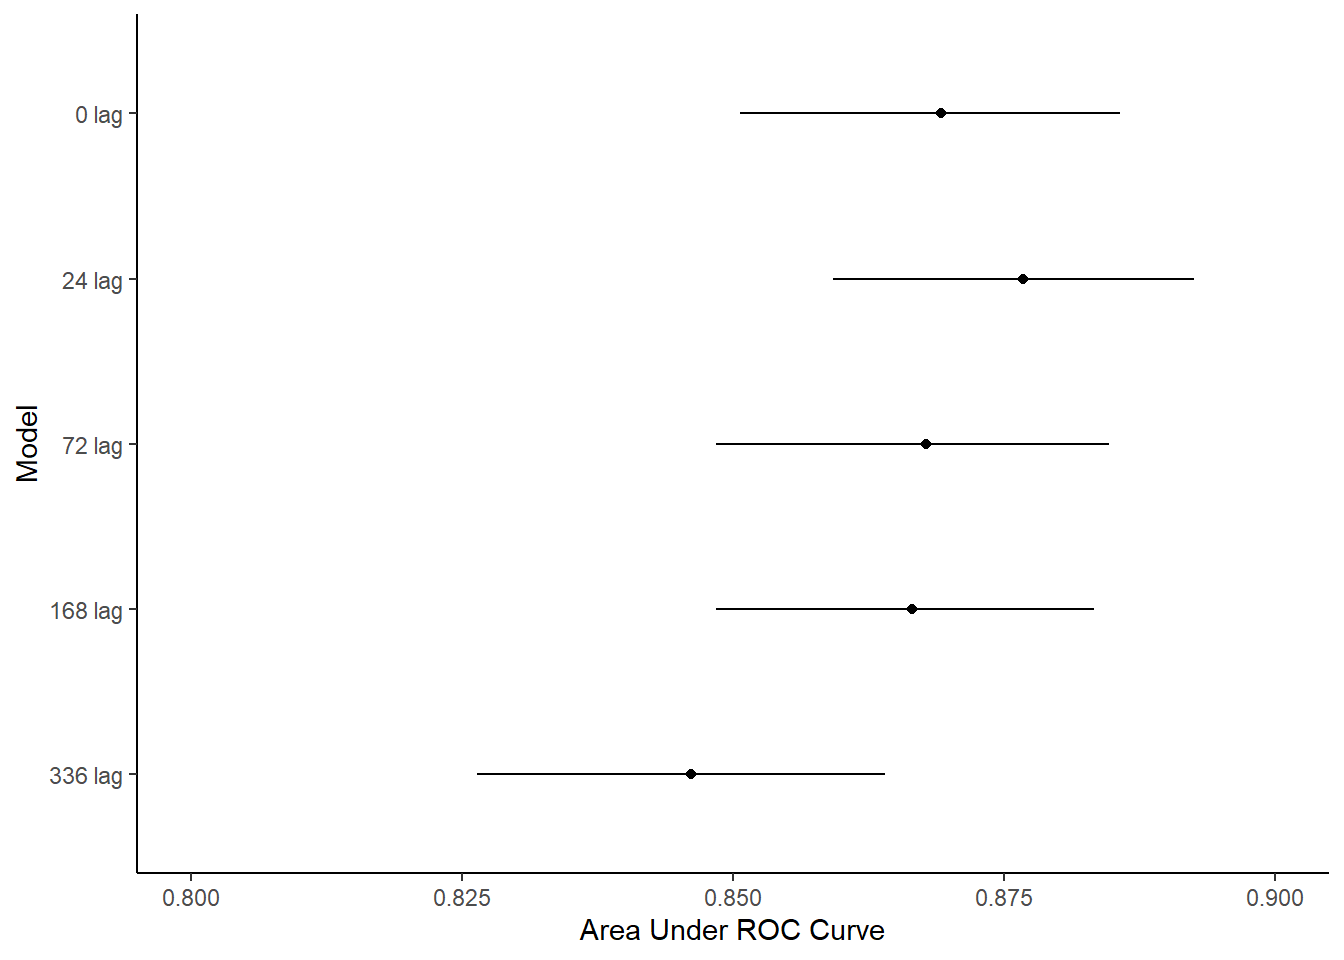

In [ ]:
test_metrics_all_pp_perf |>
  mutate(model = factor(model, levels = c("336 lag", "168 lag", "72 lag", "24 lag", "0 lag" ))) |> 
  ggplot() + 
  geom_point(aes(x = pp_median, y = model), color = "black") +
  geom_segment(mapping = aes(y = model, x = pp_lower, xend = pp_upper),
                data = test_metrics_all_pp_perf) +
  scale_x_continuous("Area Under ROC Curve", limits = c(.80, .90)) +
  ylab("Model") +
  theme_classic() +
  theme(legend.position = "none")

### Fairness of Models

### Model Comparisons

#### Baseline Contrasts

In [ ]:
ci_baseline <- pp |>
  contrast_models(list("lag0", "lag0", "lag0", "lag0"), 
                  list("lag24", "lag72", "lag168", "lag336")) |> 
  summary(size = 0) |> 
  mutate(contrast = factor(contrast, 
                           levels = c("lag0 vs lag24", "lag0 vs lag72", "lag0 vs lag168", 
                                      "lag0 vs lag336"),
                           labels = c("0 vs. 24", "0 vs. 72", 
                                      "0 vs. 168", "0 vs. 336")))

ci_median_baseline <- pp |> 
  contrast_models(list("lag0", "lag0", "lag0", "lag0"), 
                  list("lag24", "lag72", "lag168", "lag336")) |>  
  group_by(contrast) |> 
  summarize(median = quantile(difference, .5)) |> 
  mutate(contrast = factor(contrast, 
                           levels = c("lag0 vs. lag24", "lag0 vs. lag72", "lag0 vs. lag168", 
                                      "lag0 vs. lag336"),
                           labels = c("0 vs. 24", "0 vs. 72", 
                                      "0 vs. 168", "0 vs. 336")))


ci_baseline <- ci_baseline |> 
  left_join(ci_median_baseline, by = c("contrast")) 

ci_baseline |> 
  select(contrast, probability, median, lower, upper) |> 
  arrange(contrast)

# A tibble: 4 × 5
  contrast  probability   median    lower  upper
  <fct>           <dbl>    <dbl>    <dbl>  <dbl>
1 0 vs. 24        0.254 -0.00768 -0.0277  0.0116
2 0 vs. 72        0.556  0.00161 -0.0184  0.0213
3 0 vs. 168       0.585  0.00216 -0.0180  0.0216
4 0 vs. 336       0.963  0.0231   0.00195 0.0436

The median decrease in auROC for the baseline vs. 24 hour lag model was -0.008 (95% CI=\[-0.028-0.012\]), yielding a non-significant probability of 0.254 that the lagged model had worse performance. The median decrease in auROC for the baseline vs. 72 hour model was 0.002 (95% CI=\[-0.018-0.021\]), yielding a non-significant probability of 0.556 that the lagged model had worse performance. The median increase in auROC for the baseline vs. 168 hour lag model was 0.002 (95% CI=\[-0.018-0.022\]), yielding a non-significant probability of 0.585 that the lagged model had worse performance. The median increase in auROC for the baseline vs. 336 hour lag model was 0.023 (95% CI=\[0.002-0.044\]), yielding a significant probability of 0.963 that the lagged model had worse performance.

#### Adjacent Contrasts

In [ ]:
ci_lag <- pp |>
  contrast_models(list("lag24", "lag72", "lag168"), 
                  list("lag72", "lag168", "lag336")) |> 
  summary(size = 0) |> 
  mutate(contrast = factor(contrast, 
                           levels = c("lag24 vs lag72", "lag72 vs lag168", 
                                      "lag168 vs lag336"),
                           labels = c("24 vs. 72", "72 vs. 168", "168 vs. 336")))

ci_median_lag <- pp |> 
  contrast_models(list("lag24", "lag72", "lag168"), 
                  list("lag72", "lag168", "lag336")) |>  
  group_by(contrast) |> 
  summarize(median = quantile(difference, .5)) |> 
  mutate(contrast = factor(contrast, 
                           levels = c("lag24 vs. lag72", "lag72 vs. lag168", 
                                      "lag168 vs. lag336"),
                           labels = c("24 vs. 72", "72 vs. 168", "168 vs. 336")))

ci_lag <- ci_lag |> 
  left_join(ci_median_lag, by = c("contrast")) 

ci_lag |> 
  select(contrast, probability, median, lower, upper) |> 
  arrange(contrast)

# A tibble: 3 × 5
  contrast    probability   median      lower  upper
  <fct>             <dbl>    <dbl>      <dbl>  <dbl>
1 24 vs. 72         0.784 0.00937  -0.0105    0.0286
2 72 vs. 168        0.532 0.000904 -0.0192    0.0208
3 168 vs. 336       0.950 0.0204    0.0000678 0.0417

The median decrease in auROC for the 24 hour vs. 72 hour lag model was 0.009 (95% CI=\[-0.010-0.029\]), yielding a non-significant probability of 0.784 that the 72 hour lag model had worse performance than the 24 hour lag model. The median decrease in auROC for the 72 hour vs. 168 hour lag model was 0.001 (95% CI=\[-0.019-0.021\]), yielding a non-significant probability of 0.532 that the 168 hour lag model had worse performance than the 72 hour lag model. The median decrease in auROC for the 168 hour vs. 336 hour lag model was 0.020 (95% CI=\[0.000-0.042\]), yielding a significant probability of 0.950 that the 336 hour lag model had worse performance than the 168 hour lag model.

### Shapley

## Discussion

## References